Computing center:  11%|█         | 404/3673 [00:00<00:00, 4039.16it/s]/datasets/work/sa-closures-ml/work/BASIS/BASIS/modules/ringFitting.py:170: RuntimeWarning: invalid value encountered in scalar divide
  metric = std_rpk/mean_rpk
Computing center: 100%|██████████| 3673/3673 [00:00<00:00, 3942.78it/s]
/datasets/work/sa-closures-ml/work/BASIS/BASIS/modules/ringFitting.py:300: FutureWarning: AffineScalarFunc.__mod__() is deprecated. It will be removed in a future release.
  self.ring_orientation = (2*np.pi - (ufloat(avg_orientation, std_orientation) + np.pi/2)) % (2*np.pi)



Best Center: [69.  63.5], Mean RPK: 35.96+/-0.78 uas, Metric: 0.0217
Ring Width: 11.45+/-5.14 uas
Ring Orientation: 90.06 +/- 3.38 degrees CCW from North
Azimuthal Asymmetry: 0.3698+/-0.0414
Fractional Central Brightness: 1.64e-01


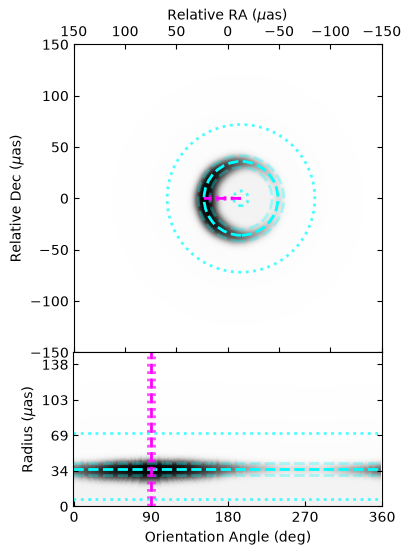

In [1]:
# Notebook for checking Bilby result in bilby_outdir/
import bilby
from BASIS.models import base
import matplotlib.pyplot as plt
from BASIS.modules import ringFitting
import numpy as np

base_outdir = 'bilby_outdir/'
runName = 'test_xsring'
models = ['xsring']
fov = 300
dim = 128

results = bilby.result.read_in_result(filename=f'{base_outdir}/{runName}/{runName}_result.json')
median_params = results.posterior.median().to_dict()

model = base.BaseModel(params = median_params, model_list = models, fov = fov, dim = dim)

# Ring fitting the median sky map
ringfitter = ringFitting.RingFit(model.sky_map(), fov=fov, interp_factor=2, blur_uas=5, total_flux=1)
ringfitter.run_all(verbose=True)

height_ratio = [6,3]
fig, ax = plt.subplots(2,1, figsize=(np.sum(height_ratio),height_ratio[0]), height_ratios=height_ratio)
plt.subplots_adjust(hspace=0.0, wspace=0.0)

save_path = None
ringfitter.plot_all(ax[0], ax[1], cmap='Greys', ratio=height_ratio, save_path=save_path)

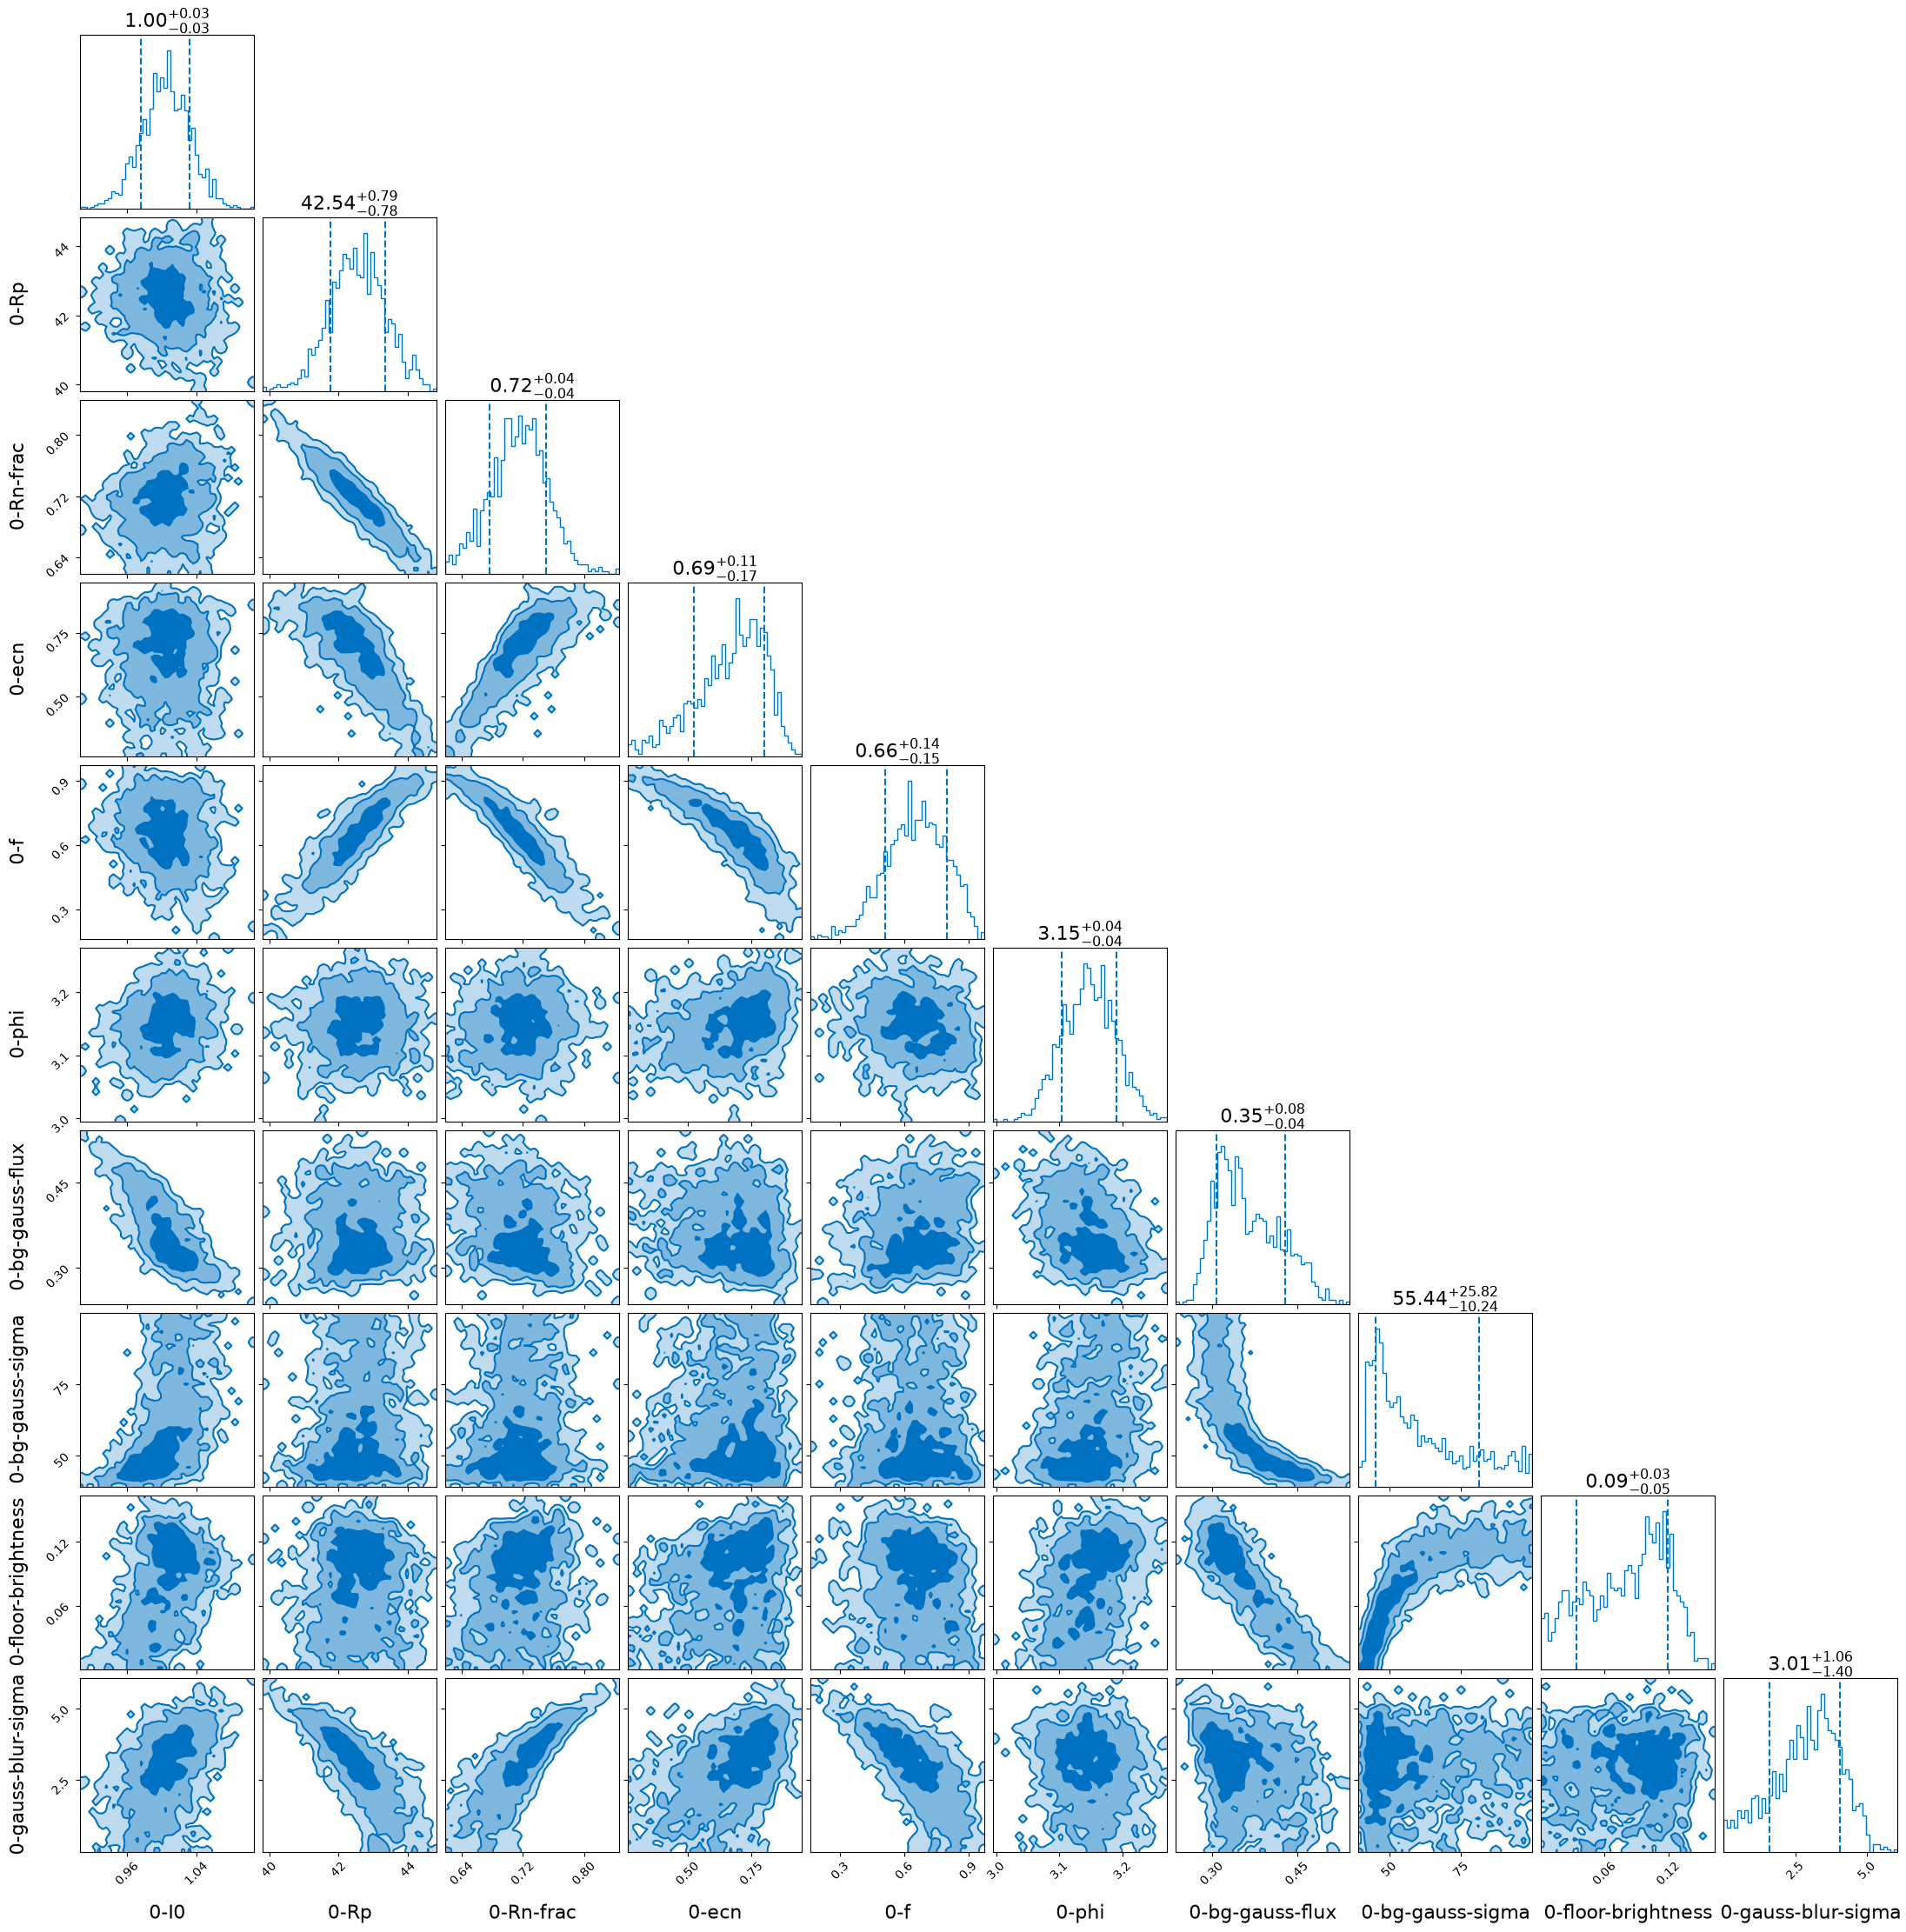

In [2]:
# Basic Corner Plot
results.plot_corner()

Text(0.5, 1.0, 'Uncertainty Map')

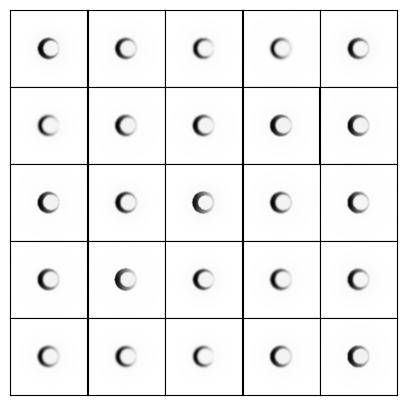

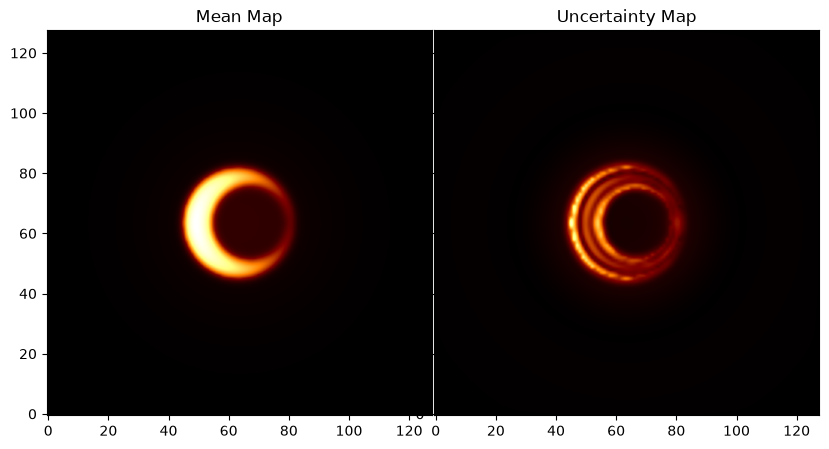

In [3]:
# Plot samples (NxN)
N = 5
samples = results.posterior.sample(N**2)
fig, ax = plt.subplots(N,N, figsize=(N,N), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.0, wspace=0.0)
imgarrs = []
for i in range(N):
    for j in range(N):
        params = samples.iloc[i*N+j].to_dict()
        model = base.BaseModel(params = params, model_list = models, fov = fov, dim = dim)
        imgarr = model.sky_map()
        imgarrs.append(imgarr)
        ax[i,j].imshow(imgarr, cmap='Greys', origin='lower', interpolation='gaussian')
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
    
# mean and uncertainty map using the posterior samples
imgarrs = np.array(imgarrs)
mean_map = np.mean(imgarrs, axis=0)
uncertainty_map = np.std(imgarrs, axis=0)

fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.subplots_adjust(hspace=0.0, wspace=0.0)
imgarr_mean = ax[0].imshow(mean_map, cmap='afmhot', origin='lower', interpolation='gaussian')
ax[0].set_title('Mean Map')
imgarr_uncertainty = ax[1].imshow(uncertainty_map, cmap='afmhot', origin='lower', interpolation='gaussian')
ax[1].set_title('Uncertainty Map')